# Multifactor Dispersion Bias — Part (ii): Verification Walkthrough

A short, results-first tour of the numerical verification of **Equation (6), Part (ii)**
(diagonal-Gram case, $G_\infty = I_k$): configure a model, run the sweep, and watch the
predicted and observed loading-direction alignment converge as the ambient dimension
$p$ grows.

For each factor $j$, as $p \to \infty$ (conditional on $F$, almost surely):

$$\sin^2\angle(h_j, \bar b_j) \;\longrightarrow\;
\underbrace{\frac{\delta^2}{n\rho_j + \delta^2}}_{\text{floor}}
\;+\;
\underbrace{\frac{n\rho_j}{n\rho_j + \delta^2}}_{\text{weight}}\cdot
\underbrace{\sin^2\angle(\hat w_j, e_j)}_{\text{rotation}}.$$

We compute the **LHS** (observed $\sin^2$ from simulated returns) and the **RHS**
(predicted from the realized factor returns) over a grid of $p$, and confirm the gap
between them shrinks to zero.

> For the engine internals and design rationale, see
> [theorem_partii_walkthrough.ipynb](theorem_partii_walkthrough.ipynb).

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment, print_summary
from fl_graphics import plot_all

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)
print("ready")

ready


## 1 — Configure

A run is a **model** (what factor model) and a **design** (the sweep + return
process). The built-in defaults are the canonical diagonal-Gram model — a market-like
factor 1 plus two zero-mean style factors, factor vols $\sigma=[.16,.08,.06]$, idio vol
$0.4$. Here we pair it with a small, fast design so the convergence trend shows up in
seconds.

In [2]:
model = ModelSpec()                       # canonical diagonal-Gram model
design = DesignSpec(                      # small smoke sweep
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40,
    random_seed=20260511,
)
# For the full canonical run, use: design = DesignSpec()   # 16,200 rows

print(f"k={model.k_factors}, factor_vols={model.factor_vols}")
print(f"n={design.n_values}, p={design.p_values}, reps={design.n_reps}")

k=3, factor_vols=[0.16, 0.08, 0.06]
n=[60], p=[200, 500, 1000, 2000, 5000], reps=40


## 2 — Run the sweep

`run_experiment(model, design, probe)` builds a fresh model per $(n, p)$ cell,
simulates `n_reps` replications of returns, runs the LHS/RHS analyses, and returns a
tidy per-replication DataFrame. One line.

In [3]:
df = run_experiment(model, design, DispersionBiasExperiment())
print("rows:", len(df), " columns:", list(df.columns))
df.head()


n=60:   0%|          | 0/5 [00:00<?, ?p/s]


n=60: 100%|██████████| 5/5 [00:00<00:00, 32.16p/s]


n=60: 100%|██████████| 5/5 [00:00<00:00, 32.09p/s]

rows: 600  columns: ['n', 'p', 'j', 'sin2_j', 'rhs', 'gap', 'floor', 'rotation', 'rho']


,n,p,j,sin2_j,rhs,gap,floor,rotation,rho
0,60,200,1,0.047544,0.047242,0.000302,0.043080,0.004350,0.059233
1,60,200,2,0.242107,0.258549,-0.016442,0.253532,0.006721,0.007851
2,60,200,3,0.775638,0.501169,0.274469,0.499644,0.003048,0.002670
3,60,200,1,0.062322,0.061266,0.001056,0.056903,0.004627,0.044197
4,60,200,2,0.514176,0.351749,0.162428,0.344237,0.011455,0.005080


## 3 — The confirmation

The RMSE of the gap $(\sin^2\angle - \text{RHS})$ per $(n, p, j)$ should **fall as $p$
grows** — that decline is the numerical confirmation of the theorem. The weakest factor
($j=3$) converges slowest, as the theory predicts.

In [4]:
print_summary(df)


RMSE of (sin²∠ − RHS)  [smaller is better; should → 0 as p grows]

            j=1     j=2     j=3
n  p                           
60 200  0.00476 0.07338 0.20212
   500  0.00301 0.11056 0.11743
   1000 0.00232 0.02314 0.03345
   2000 0.00202 0.01864 0.02228
   5000 0.00131 0.02921 0.02774



## 4 — Figures

The gap-vs-$p$ convergence (should trend to zero) and the observed-vs-predicted
scatter at the second-largest $p$ (should hug the 45° line).

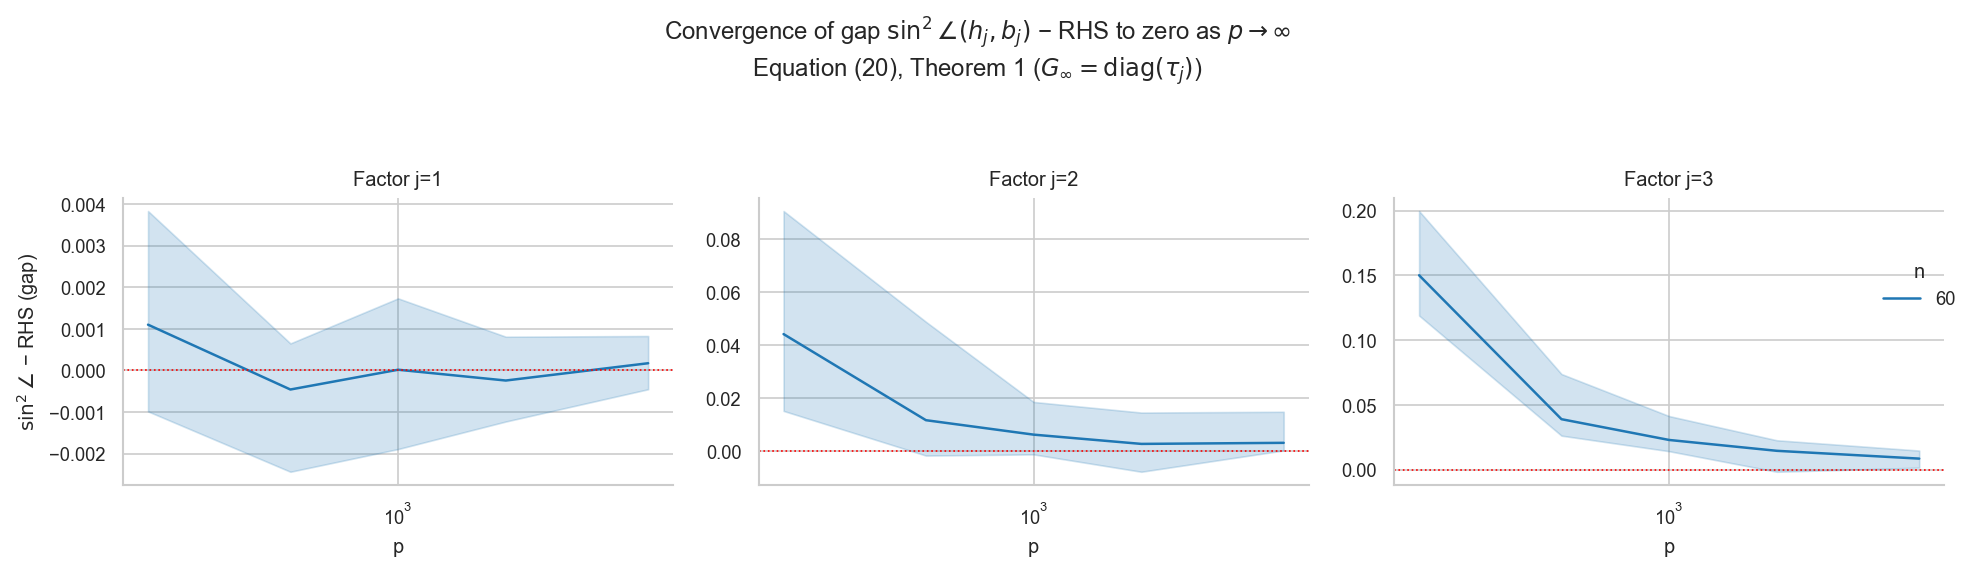

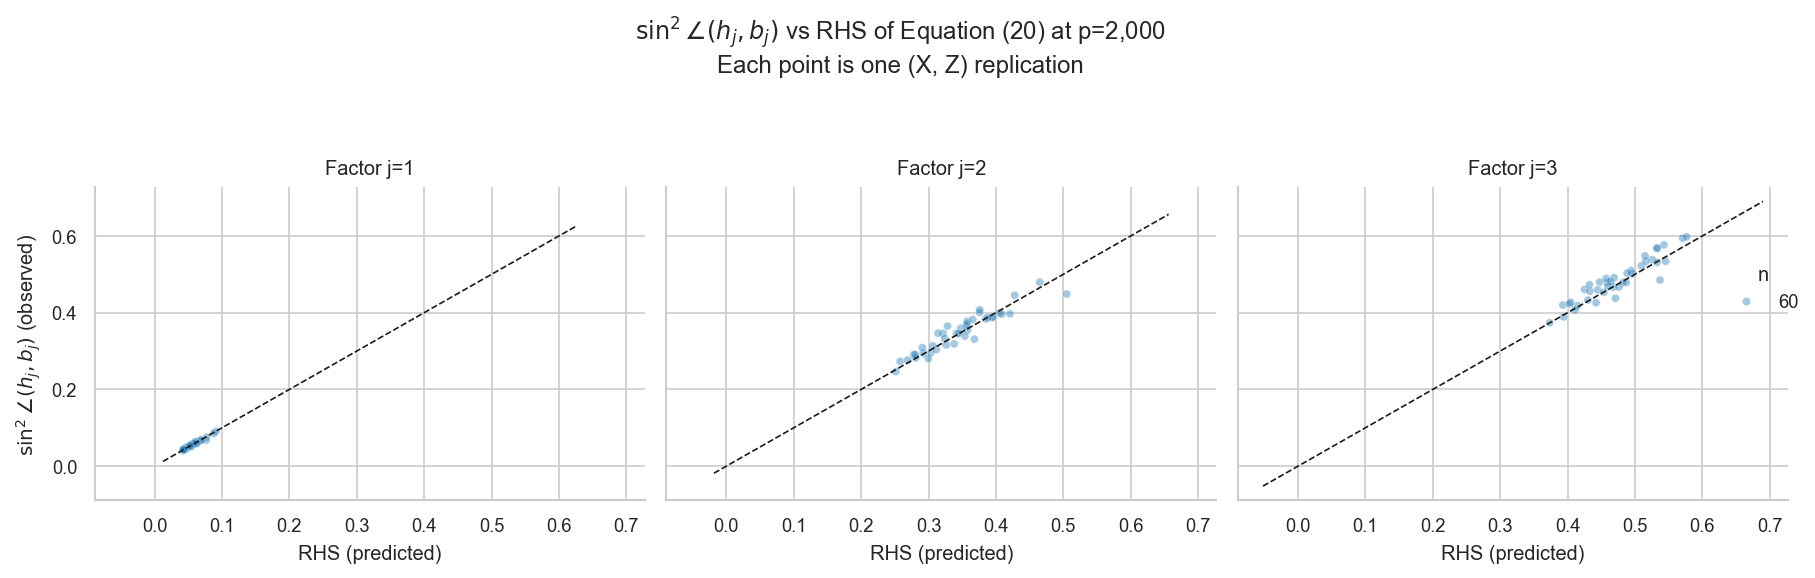

In [5]:
from IPython.display import Image, display

plot_all(df, OUT_DIR, n_show=60)
for fname in ["fig_theorem1_convergence_v2.png", "fig_theorem1_scatter_v2.png"]:
    display(Image(filename=str(OUT_DIR / fname)))

## 5 — Cleaner convergence: nested sampling

Set `sampling="nested"` to draw one superset at $p_{\max}$ per replicate and take each
smaller $p$ as its first-$p$ asset subset — so every $p$ sees the *same* assets. That
removes the cross-$p$ sampling noise and gives a clean monotone-in-$p$ curve. Only the
one field changes; the model and the probe are identical.

In [6]:
nested = DesignSpec(
    n_values=[60], p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40, random_seed=20260511,
    sampling="nested",
)
df_nested = run_experiment(model, nested, DispersionBiasExperiment())

rmse = (df_nested[df_nested.j == 1].groupby("p")["gap"]
        .apply(lambda g: float((g ** 2).mean() ** 0.5)))
print("nested RMSE(j=1) by p (falls monotonically):")
print(rmse.round(4).to_string())


replicate:   0%|          | 0/40 [00:00<?, ?rep/s]


replicate:  35%|███▌      | 14/40 [00:00<00:00, 134.24rep/s]


replicate:  78%|███████▊  | 31/40 [00:00<00:00, 151.74rep/s]


replicate: 100%|██████████| 40/40 [00:00<00:00, 152.54rep/s]

nested RMSE(j=1) by p (falls monotonically):
p
200     0.0059
500     0.0039
1000    0.0024
2000    0.0018
5000    0.0012


## Running the full experiment

Swap in `design = DesignSpec()` above for the canonical run ($3$ factors $\times\,300$
reps $\times\,6$ $p$-values $\times\,3$ $n$-values $= 16{,}200$ rows), or run it from the
command line:

```bash
python sim_theorem_partii.py --plot-save                      # built-in defaults
python sim_theorem_partii.py sim_thmptii_spec.json --plot-save # single-file spec
python sim_theorem_partii.py experiment_spec.nested.example.json --plot-save
```

Outputs (parquet + the three figures) land in `results/MM-DD_run_NN/`.